In [1]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"hashshamabid","key":"b135295876cbe9a5178d92010c8eb7c5"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [27]:
!pip install catboost
!pip install lightgbm
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.6 MB/s eta 0:00:00


##Importing Housing Price dataset


In [3]:
# !kaggle datasets list

!kaggle datasets download -d shree1992/housedata

Dataset URL: https://www.kaggle.com/datasets/shree1992/housedata
License(s): unknown
100% 432k/432k [00:00<00:00, 137MB/s]



In [4]:
!unzip /content/housedata.zip

Archive:  /content/housedata.zip
  inflating: data.csv                
  inflating: data.dat                
  inflating: output.csv              


In [5]:
import pandas as pd

df = pd.read_csv('/content/data.csv')
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [6]:
df_1 = pd.read_csv("/content/output.csv")
df_1.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


## We are checking and Cleaning the data, and converting to 0 and 1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [8]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [9]:
#Elaborating the dates now


df["date"].value_counts()
df["date"] = pd.to_datetime(df["date"])

## I need YEar here so i can split the data

df["year_sold"] = df["date"].dt.year
df["month_sold"] = df["date"].dt.month
df["day_sold"] = df["date"].dt.day

##Find the the house age
df["house_age"] = df["year_sold"] - df["yr_built"]

##house Renovated
df["was_renovated"] = df["yr_renovated"].apply(lambda yr: 1 if yr > 0 else 0)

## year since renovation
df["year_since_renovation"] = df['year_sold'] - df['yr_renovated']

df.loc[df["was_renovated"]==0,"year_since_renovation"] = df["house_age"]

df["effective_age"] = df["house_age"]

df.loc[df["was_renovated"]==1,"effective_age"] = df["year_since_renovation"]

df = df.drop(["date","yr_renovated","yr_built"],axis=1)

# df.head()
##
##



In [10]:
df = df.drop(["street","country"],axis=1)


In [11]:
df.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'city', 'statezip', 'year_sold', 'month_sold', 'day_sold', 'house_age',
       'was_renovated', 'year_since_renovation', 'effective_age'],
      dtype='object')

In [12]:
import numpy as np

X = df.drop("price",axis=1)
y = df["price"]

y = np.log1p(y)
y.head()

,price
0,12.653962
1,14.684291
2,12.742569
3,12.948012
4,13.217675


In [13]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

num_col = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
        'year_sold', 'month_sold', 'day_sold', 'house_age',
       'was_renovated', 'year_since_renovation', 'effective_age']

text_col = ['city', 'statezip']


transformer = ColumnTransformer([
    ("num",Pipeline([
        ("imputer",SimpleImputer(strategy="mean")),
        ("scaler",StandardScaler())
    ]),num_col),
    ("text",Pipeline([
        ("imputer",SimpleImputer(strategy="most_frequent")),
        ("encoder",OneHotEncoder(handle_unknown="ignore"))
    ]),text_col)])




## Spilitting the data for test and train, and downloading various models to check which model perform better

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np


x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

models = {
    "Random Forest" : RandomForestRegressor(
        n_estimators=500,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42
    ),
    "Linear Regression" : LinearRegression(),
    "Ridge" : Ridge(
        alpha=1.0,
        fit_intercept=True,
        solver='auto',
    ),
    "Decision Tree" : DecisionTreeRegressor(
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
    ),
    "KNN" : KNeighborsRegressor(
        n_neighbors=5,
        weights='uniform',
        algorithm='auto',
        leaf_size=30
    ),
    "Gradient Boosting" : GradientBoostingRegressor(
        n_estimators=500,
        learning_rate=0.1,
        max_depth=3,
    ),
    "SVR" : SVR(
        kernel='rbf',
        degree=3,
        gamma='scale',
    ),
    "xgboost" : XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth = 6,
        random_state=42
    ),
    "lightGBM" : LGBMRegressor(
        n_estimators=500,
        learning_rate=0.01,
        random_state=42
    ),
    "catboost" : CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth = 6,
        loss_function="RMSE",
        random_state=42,
    )
}


results = []

for name,model in models.items():
  my_pipeline = Pipeline([
      ("preprocessor",transformer),
      ("model",model)
  ])
  my_pipeline.fit(x_train,y_train)
  preds = my_pipeline.predict(x_test)
  price_preds = np.expm1(preds)
  price_test = np.expm1(y_test)
  results.append({
      "model" : name,
      "mae" : mean_absolute_error(price_test,price_preds),
      "rmse" : np.sqrt(mean_squared_error(price_test,price_preds)),
      "r2_score" : r2_score(price_test,price_preds)

  })



results

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000583 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1508
[LightGBM] [Info] Number of data points in the train set: 3220, number of used features: 102
[LightGBM] [Info] Start training from score 12.923933


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


0:	learn: 1.4537359	total: 48.7ms	remaining: 24.3s
1:	learn: 1.4501147	total: 51.2ms	remaining: 12.7s
2:	learn: 1.4460795	total: 53.3ms	remaining: 8.82s
3:	learn: 1.4430411	total: 55.1ms	remaining: 6.84s
4:	learn: 1.4396832	total: 56.9ms	remaining: 5.64s
5:	learn: 1.4353175	total: 58.9ms	remaining: 4.85s
6:	learn: 1.4287210	total: 60.8ms	remaining: 4.28s
7:	learn: 1.4235829	total: 62.8ms	remaining: 3.86s
8:	learn: 1.4203418	total: 64.7ms	remaining: 3.53s
9:	learn: 1.4174801	total: 66.7ms	remaining: 3.27s
10:	learn: 1.4151599	total: 68.7ms	remaining: 3.05s
11:	learn: 1.4112183	total: 70.6ms	remaining: 2.87s
12:	learn: 1.4095056	total: 72.8ms	remaining: 2.73s
13:	learn: 1.4069304	total: 74.9ms	remaining: 2.6s
14:	learn: 1.4018408	total: 76.9ms	remaining: 2.49s
15:	learn: 1.3997560	total: 78.9ms	remaining: 2.38s
16:	learn: 1.3976736	total: 80.8ms	remaining: 2.3s
17:	learn: 1.3955845	total: 82.9ms	remaining: 2.22s
18:	learn: 1.3930037	total: 84.9ms	remaining: 2.15s
19:	learn: 1.3902583	tot

[{'model': 'Random Forest',
  'mae': 175051.7779124527,
  'rmse': np.float64(837066.5404592619),
  'r2_score': 0.0301356921113084},
 {'model': 'Linear Regression',
  'mae': 194909.38477705212,
  'rmse': np.float64(845022.798371248),
  'r2_score': 0.011611088521529922},
 {'model': 'Ridge',
  'mae': 194121.35981517992,
  'rmse': np.float64(846526.4138513088),
  'r2_score': 0.008090522950171763},
 {'model': 'Decision Tree',
  'mae': 199055.93660088195,
  'rmse': np.float64(853123.9259787877),
  'r2_score': -0.007430873602765731},
 {'model': 'KNN',
  'mae': 188508.91552784867,
  'rmse': np.float64(839280.1947397193),
  'r2_score': 0.0249992232391677},
 {'model': 'Gradient Boosting',
  'mae': 181564.06745955927,
  'rmse': np.float64(843460.6960400179),
  'r2_score': 0.015261966451639575},
 {'model': 'SVR',
  'mae': 134558.68213075373,
  'rmse': np.float64(810156.8558762253),
  'r2_score': 0.09149099742311351},
 {'model': 'xgboost',
  'mae': 167466.1413530248,
  'rmse': np.float64(831887.293

In [29]:
results_df = pd.DataFrame(results)
results_df

,model,mae,rmse,r2_score
0,Random Forest,175051.777912,837066.540459,0.030136
1,Linear Regression,194909.384777,845022.798371,0.011611
2,Ridge,194121.359815,846526.413851,0.008091
3,Decision Tree,199055.936601,853123.925979,-0.007431
4,KNN,188508.915528,839280.194740,0.024999
5,Gradient Boosting,181564.067460,843460.696040,0.015262
6,SVR,134558.682131,810156.855876,0.091491
7,xgboost,167466.141353,831887.293486,0.042100
8,lightGBM,201863.695132,843386.671714,0.015435
9,catboost,180365.701147,835216.418283,0.034418


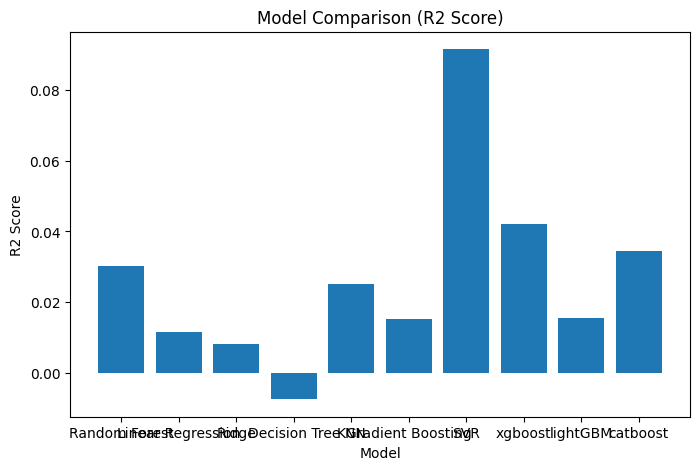

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
plt.bar(results_df["model"],results_df["r2_score"])
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.title("Model Comparison (R2 Score)")
plt.show()

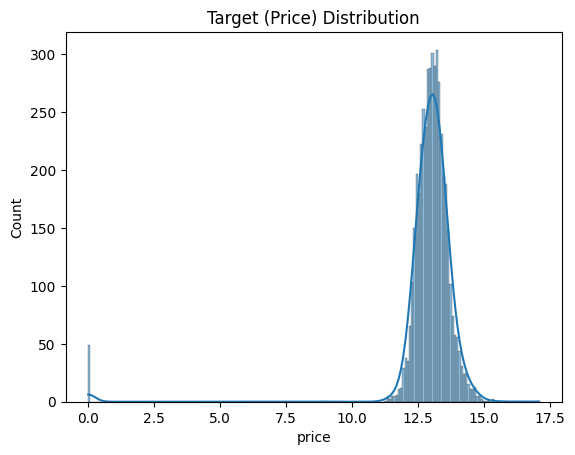

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(y, kde=True)
plt.title("Target (Price) Distribution")
plt.show()

In [32]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():
  my_pipeline = Pipeline([
      ("preprocessor",transformer),
      ("model",model)
  ])
  my_pipeline.fit(x_train,y_train)

  scores = cross_val_score(my_pipeline,x_train,y_train,cv=5,scoring="r2")
  print(name)
  print("Mean R2 score :",scores.mean())


Random Forest
Mean R2 score : -0.0463415854983106
Linear Regression
Mean R2 score : 0.004709266037004145
Ridge
Mean R2 score : 0.04447491559714343
Decision Tree
Mean R2 score : -0.6406427821937083
KNN
Mean R2 score : -0.11399242081241359
Gradient Boosting
Mean R2 score : -0.24127576601402137
SVR
Mean R2 score : 0.07725241201415389
xgboost
Mean R2 score : -0.18727972396318168
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000601 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1508
[LightGBM] [Info] Number of data points in the train set: 3220, number of used features: 102
[LightGBM] [Info] Start training from score 12.923933
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000132 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1472
[LightGBM] [Info] N

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000174 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1467
[LightGBM] [Info] Number of data points in the train set: 2576, number of used features: 91
[LightGBM] [Info] Start training from score 12.951736


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000760 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1472
[LightGBM] [Info] Number of data points in the train set: 2576, number of used features: 94
[LightGBM] [Info] Start training from score 12.923270


...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000254 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1474
[LightGBM] [Info] Number of data points in the train set: 2576, number of used features: 94
[LightGBM] [Info] Start training from score 12.911268


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000137 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1478
[LightGBM] [Info] Number of data points in the train set: 2576, number of used features: 92
[LightGBM] [Info] Start training from score 12.916659


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


lightGBM
Mean R2 score : 0.004181147410395459
0:	learn: 1.4537359	total: 2.88ms	remaining: 1.44s
1:	learn: 1.4501147	total: 4.81ms	remaining: 1.2s
2:	learn: 1.4460795	total: 6.68ms	remaining: 1.11s
3:	learn: 1.4430411	total: 8.74ms	remaining: 1.08s
4:	learn: 1.4396832	total: 10.7ms	remaining: 1.06s
5:	learn: 1.4353175	total: 12.6ms	remaining: 1.04s
6:	learn: 1.4287210	total: 14.5ms	remaining: 1.02s
7:	learn: 1.4235829	total: 16.5ms	remaining: 1.02s
8:	learn: 1.4203418	total: 18.6ms	remaining: 1.01s
9:	learn: 1.4174801	total: 20.6ms	remaining: 1.01s
10:	learn: 1.4151599	total: 22.6ms	remaining: 1s
11:	learn: 1.4112183	total: 24.4ms	remaining: 993ms
12:	learn: 1.4095056	total: 26.4ms	remaining: 988ms
13:	learn: 1.4069304	total: 28.4ms	remaining: 984ms
14:	learn: 1.4018408	total: 30.5ms	remaining: 985ms
15:	learn: 1.3997560	total: 32.4ms	remaining: 981ms
16:	learn: 1.3976736	total: 34.2ms	remaining: 971ms
17:	learn: 1.3955845	total: 36.1ms	remaining: 966ms
18:	learn: 1.3930037	total: 38.1

###We choose the SVM as it showing the best performane

Test MAE :  134558.68213075373


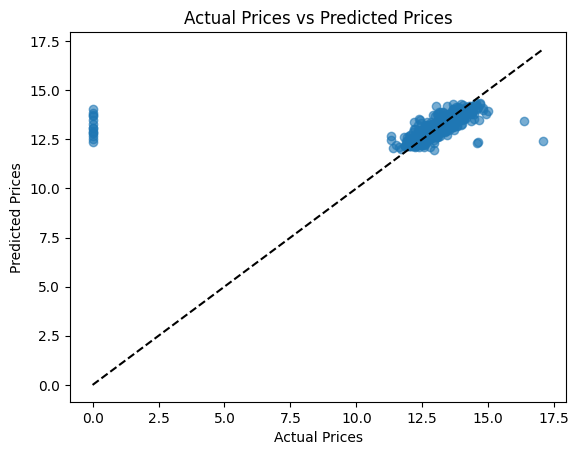

Test MAE :  0.3112672567743121


In [33]:
from sklearn.metrics import mean_absolute_error

best_pipeline = Pipeline ([
    ("preprocessor",transformer),
    ("model",SVR(kernel="rbf",degree=3,gamma="scale"))
])

best_pipeline.fit(x_train,y_train)

y_pred_svm = best_pipeline.predict(x_test)

price_pred = np.expm1(y_pred_svm)
price_test = np.expm1(y_test)

print("Test MAE : ", mean_absolute_error(price_test,price_pred))

plt.scatter(y_test,y_pred_svm,alpha=0.6)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],"k--")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs Predicted Prices")
plt.show()

print("Test MAE : ", mean_absolute_error(y_test,y_pred_svm))

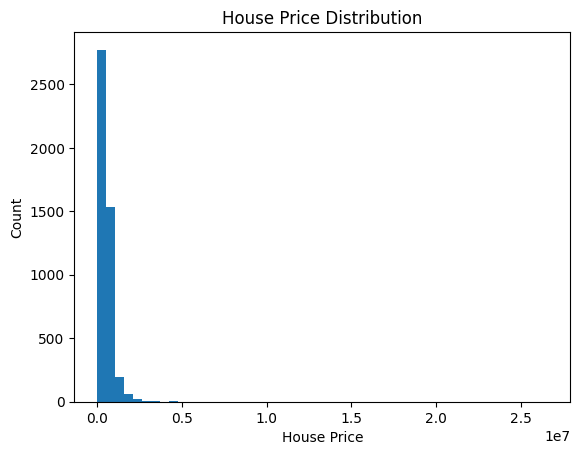

In [34]:
plt.hist(df["price"],bins=50)
plt.title("House Price Distribution")
plt.xlabel("House Price")
plt.ylabel("Count")
plt.show()

In [35]:
import joblib

joblib.dump(best_pipeline,"house_price_prediction_model.pkl")
print("Saved")

Saved
